## Piecewise-linear instability, 2 balloons

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Piecewise-linear balloon model from Sec. II.B
# s = 0   : first ascending branch
# s = 0.5 : descending branch
# s = 1   : second ascending branch
# ------------------------------------------------------------

def branch_params(m, a, b, s):
    """
    Return g, h for P(V) = g V + h.

    From paper:
        g = -m if s = 1/2, otherwise m

        h = 0                  if s = 0
            2 m a              if s = 1/2
            2 m (a - b)        if s = 1
    """
    if s == 0:
        return m, 0.0
    elif s == 0.5:
        return -m, 2.0 * m * a
    elif s == 1:
        return m, 2.0 * m * (a - b)
    else:
        raise ValueError("State must be 0, 0.5, or 1.")


def volume_range(a, b, s):
    """
    Valid volume interval for a branch.
    """
    if s == 0:
        return 0.0, a
    elif s == 0.5:
        return a, b
    elif s == 1:
        return b, np.inf
    else:
        raise ValueError("State must be 0, 0.5, or 1.")


def solve_two_balloon_state(VT, p1, p2, s1, s2):
    """
    Solve for V1, V2, P for a fixed total volume VT
    and a fixed branch/state pair (s1, s2).

    Equations:
        P1(V1) = P2(V2)
        V1 + V2 = VT
    """
    m1, a1, b1 = p1["m"], p1["a"], p1["b"]
    m2, a2, b2 = p2["m"], p2["a"], p2["b"]

    g1, h1 = branch_params(m1, a1, b1, s1)
    g2, h2 = branch_params(m2, a2, b2, s2)

    # g1 V1 + h1 = g2 V2 + h2
    # V2 = VT - V1
    # g1 V1 + h1 = g2 (VT - V1) + h2
    # (g1 + g2) V1 = g2 VT + h2 - h1
    denom = g1 + g2

    if abs(denom) < 1e-12:
        return None

    V1 = (g2 * VT + h2 - h1) / denom
    V2 = VT - V1
    P = g1 * V1 + h1

    return V1, V2, P


def is_valid_branch(V, a, b, s, tol=1e-9):
    """
    Check whether volume V lies inside the branch interval.
    """
    lo, hi = volume_range(a, b, s)

    if np.isinf(hi):
        return V >= lo - tol
    else:
        return (V >= lo - tol) and (V <= hi + tol)


def is_stable_state(s1, s2):
    """
    For the piecewise-linear N-shaped curve:
        ascending branches are stable
        descending branch s = 1/2 is unstable

    For visualization, mark a configuration stable only when both
    balloons are on ascending branches.
    """
    return (s1 != 0.5) and (s2 != 0.5)


def compute_configuration_space(p1, p2, VT_values):
    """
    Compute all valid configuration-space branches for two balloons.
    """
    states = [0, 0.5, 1]
    branches = {}

    for s1 in states:
        for s2 in states:
            key = (s1, s2)
            data = {
                "VT": [],
                "V1": [],
                "V2": [],
                "P": [],
                "stable": is_stable_state(s1, s2),
            }

            for VT in VT_values:
                sol = solve_two_balloon_state(VT, p1, p2, s1, s2)
                if sol is None:
                    continue

                V1, V2, P = sol

                ok1 = is_valid_branch(V1, p1["a"], p1["b"], s1)
                ok2 = is_valid_branch(V2, p2["a"], p2["b"], s2)

                if ok1 and ok2 and V1 >= 0 and V2 >= 0:
                    data["VT"].append(VT)
                    data["V1"].append(V1)
                    data["V2"].append(V2)
                    data["P"].append(P)

            branches[key] = data

    return branches



## Plotting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Example parameters
# ------------------------------------------------------------
# a = volume at local pressure maximum
# b = volume at local pressure minimum
# m = absolute slope magnitude
#
# Changing a, b, m changes the topology / transition behavior.
# ------------------------------------------------------------

def get_branch_color(balloon_id, s):
    """
    Balloon 1: blue family
    Balloon 2: orange family

    s = 0   : darkest
    s = 0.5 : lighter
    s = 1   : lightest
    """
    colors = {
        1: {
            0:   "#1f4e79",  # dark blue
            0.5: "#5b9bd5",  # medium blue
            1:   "#cfe2f3",  # light blue
        },
        2: {
            0:   "#b45f06",  # dark orange
            0.5: "#f6b26b",  # medium orange
            1:   "#fce5cd",  # light orange
        },
    }

    return colors[balloon_id][s]

def plot_pressure_volume_curves(p1, p2, Vmax=8.0, n=500):
    """
    Plot individual piecewise-linear P-V curves.

    Balloon 1 uses blue shades.
    Balloon 2 uses orange shades.

    For each balloon:
        s = 0   darkest
        s = 0.5 lighter
        s = 1   lightest
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    for balloon_id, p, label in [
        (1, p1, "Balloon 1"),
        (2, p2, "Balloon 2"),
    ]:
        m, a, b = p["m"], p["a"], p["b"]

        # Branch s = 0
        V0 = np.linspace(0, a, n)
        P0 = m * V0

        # Branch s = 1/2
        Vh = np.linspace(a, b, n)
        Ph = -m * Vh + 2 * m * a

        # Branch s = 1
        V1 = np.linspace(b, Vmax, n)
        P1 = m * V1 + 2 * m * (a - b)

        ax.plot(
            V0,
            P0,
            color=get_branch_color(balloon_id, 0),
            linewidth=2.5,
            label=f"{label}, s=0",
        )

        ax.plot(
            Vh,
            Ph,
            color=get_branch_color(balloon_id, 0.5),
            linewidth=2.5,
            linestyle="--",
            label=f"{label}, s=1/2",
        )

        ax.plot(
            V1,
            P1,
            color=get_branch_color(balloon_id, 1),
            linewidth=2.5,
            label=f"{label}, s=1",
        )

    ax.set_xlabel(r"Volume $V$")
    ax.set_ylabel(r"Pressure $P$")
    ax.set_title("Piecewise-linear balloon P-V curves")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def hex_to_rgb01(hex_color):
    """
    Convert hex color to RGB in [0, 1].
    """
    hex_color = hex_color.lstrip("#")
    return np.array([
        int(hex_color[0:2], 16),
        int(hex_color[2:4], 16),
        int(hex_color[4:6], 16),
    ]) / 255.0


def mixed_state_color(s1, s2, weight1=0.5):
    """
    Mix balloon 1 color for s1 and balloon 2 color for s2.
    """
    c1 = hex_to_rgb01(get_branch_color(1, s1))
    c2 = hex_to_rgb01(get_branch_color(2, s2))

    return weight1 * c1 + (1.0 - weight1) * c2


def plot_configuration_space(branches, VT_lines=True):
    """
    Plot V2 vs V1 configuration space.

    Branch color is determined by the pair of balloon states:
        color = mix(color_balloon1[s1], color_balloon2[s2])

    Solid = stable branch.
    Dashed = unstable branch.
    Gray diagonal lines = constant total volume V_T = V1 + V2.
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    all_V1 = []
    all_V2 = []

    # Plot configuration-space branches
    for state, data in branches.items():
        s1, s2 = state

        V1 = np.array(data["V1"])
        V2 = np.array(data["V2"])

        if len(V1) < 2:
            continue

        all_V1.extend(V1)
        all_V2.extend(V2)

        color = mixed_state_color(s1, s2)

        if data["stable"]:
            linestyle = "-"
            linewidth = 2.7
        else:
            linestyle = "--"
            linewidth = 2.2

        ax.plot(
            V1,
            V2,
            linestyle=linestyle,
            linewidth=linewidth,
            color=color,
            label=f"{state}",
            zorder=3,
        )

        mid = len(V1) // 2
        ax.text(
            V1[mid],
            V2[mid],
            f"{state}",
            fontsize=9,
            color=color,
            zorder=4,
        )

    all_V1 = np.array(all_V1)
    all_V2 = np.array(all_V2)

    xmax = np.max(all_V1) * 1.10
    ymax = np.max(all_V2) * 1.10

    xmin = 0.0
    ymin = 0.0

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Constant total-volume lines: V1 + V2 = VT
    if VT_lines:
        VT_values = np.linspace(0.0, xmax + ymax, 18)

        for VT in VT_values:
            points = []

            # x = xmin
            x = xmin
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # x = xmax
            x = xmax
            y = VT - x
            if ymin <= y <= ymax:
                points.append((x, y))

            # y = ymin
            y = ymin
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # y = ymax
            y = ymax
            x = VT - y
            if xmin <= x <= xmax:
                points.append((x, y))

            # Remove duplicates
            unique_points = []
            for p in points:
                if p not in unique_points:
                    unique_points.append(p)

            if len(unique_points) >= 2:
                p0, p1 = unique_points[0], unique_points[1]

                ax.plot(
                    [p0[0], p1[0]],
                    [p0[1], p1[1]],
                    color="gray",
                    alpha=0.4,
                    linewidth=0.9,
                    zorder=1,
                )

    ax.set_xlabel(r"$V_1$")
    ax.set_ylabel(r"$V_2$")
    ax.set_title("Configuration space for two volume-controlled balloons")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.12, zorder=0)
    ax.legend(title=r"$(s_1,s_2)$", fontsize=8)
    plt.tight_layout()
    plt.show()

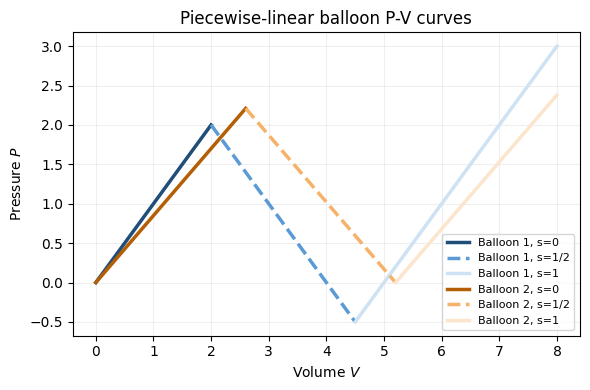

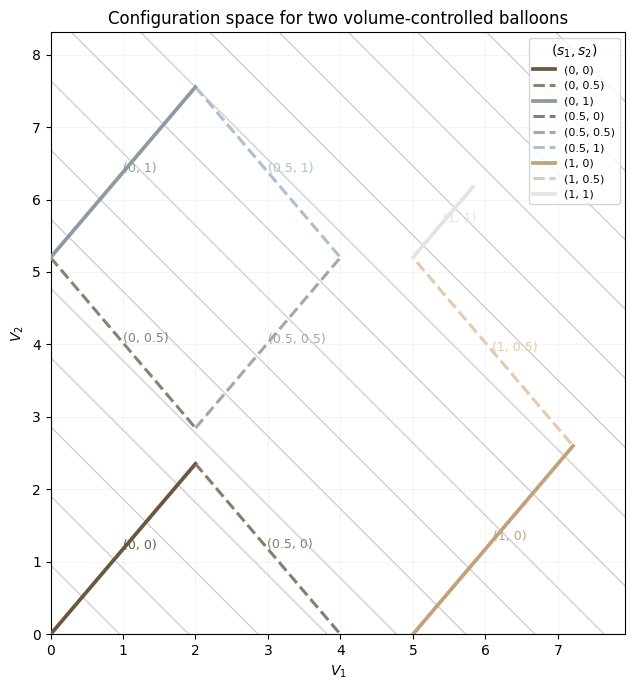

In [20]:
balloon1 = {
    "m": 1.0,
    "a": 2.0,
    "b": 4.5,
}

balloon2 = {
    "m": 0.85,
    "a": 2.6,
    "b": 5.2,
}

VT_values = np.linspace(0.0, 12.0, 2000)

branches = compute_configuration_space(balloon1, balloon2, VT_values)

plot_pressure_volume_curves(balloon1, balloon2, Vmax=8.0)
plot_configuration_space(branches)

# Fit Piecewise linear to data

In [26]:
FOLDER = r"D:\\ucla_research\\Projects\\arduino_sketches\\arduinoPy\\sensor_logs\\pciPV\WHPeakCompare"

In [39]:
import pandas as pd

def balloon_piecewise_linear_model_general(x, g0, g_mid, g1, a, b):
    """
    Piecewise-linear balloon instability model with different slopes
    on each branch.

    Branch 1:
        P(x) = g0 * x                         for x <= a

    Branch 2:
        P(x) = g_mid * x + h_mid              for a < x <= b

    Branch 3:
        P(x) = g1 * x + h1                    for x > b

    The intercepts are chosen so the curve is continuous at x = a and x = b.
    """

    x = np.asarray(x, dtype=float)

    # Continuity at x = a:
    # g0 * a = g_mid * a + h_mid
    h_mid = (g0 - g_mid) * a

    # Continuity at x = b:
    # g_mid * b + h_mid = g1 * b + h1
    h1 = (g_mid - g1) * b + h_mid

    y = np.empty_like(x, dtype=float)

    mask1 = x <= a
    mask2 = (x > a) & (x <= b)
    mask3 = x > b

    y[mask1] = g0 * x[mask1]
    y[mask2] = g_mid * x[mask2] + h_mid
    y[mask3] = g1 * x[mask3] + h1

    return y


def balloon_piecewise_linear_model_general_with_offset(
    x,
    g0,
    g_mid,
    g1,
    a,
    b,
    p0,
):
    """
    Same model with pressure offset p0.
    """

    return p0 + balloon_piecewise_linear_model_general(
        x,
        g0=g0,
        g_mid=g_mid,
        g1=g1,
        a=a,
        b=b,
    )


from scipy.optimize import least_squares

def fit_balloon_piecewise_linear_mass(
    df,
    x_col="cumulative mass (kg)",
    p_col="pressure (kPa)",
    time_col="time normed (s)",
    t_min=6.0,
    use_offset=True,
):
    """
    Fit the generalized piecewise-linear balloon instability model.

    The model is:

        branch 0:      P = g0 x + p0
        branch 1/2:    P = g_mid x + h_mid + p0
        branch 1:      P = g1 x + h1 + p0

    with continuity enforced at x = a and x = b.

    Constraints:
        g0 > 0
        g_mid < 0
        g1 > 0
        a < b
    """

    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[p_col], errors="coerce").to_numpy(dtype=float)
    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(t)
    valid &= t >= float(t_min)

    x = x[valid]
    y = y[valid]

    if x.size < 7:
        raise ValueError("Not enough valid data points to fit the generalized piecewise-linear model.")

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_min = float(np.min(x))
    x_max = float(np.max(x))
    x_range = x_max - x_min

    if x_range <= 0:
        raise ValueError("x data has zero range; cannot fit piecewise model.")

    # Initial breakpoint guesses
    a0 = x_min + 0.35 * x_range
    b0 = x_min + 0.70 * x_range

    # Estimate rough slope scale
    slope_scale = max(abs(np.max(y) - np.min(y)) / x_range, 1e-6)

    g0_0 = slope_scale
    g_mid_0 = -slope_scale
    g1_0 = slope_scale

    p00 = float(y[0] - balloon_piecewise_linear_model_general(
        x[0],
        g0=g0_0,
        g_mid=g_mid_0,
        g1=g1_0,
        a=a0,
        b=b0,
    ))

    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    def logit(q):
        q = np.clip(q, 1e-6, 1.0 - 1e-6)
        return np.log(q / (1.0 - q))

    def unpack(theta):
        # Enforce:
        # g0 > 0
        # g_mid < 0
        # g1 > 0
        g0 = np.exp(theta[0])
        g_mid = -np.exp(theta[1])
        g1 = np.exp(theta[2])

        alpha = theta[3]
        beta = theta[4]

        a = x_min + sigmoid(alpha) * x_range
        b = a + sigmoid(beta) * (x_max - a)

        if use_offset:
            p0 = theta[5]
        else:
            p0 = 0.0

        return g0, g_mid, g1, a, b, p0

    def residual(theta):
        g0, g_mid, g1, a, b, p0 = unpack(theta)

        y_hat = balloon_piecewise_linear_model_general_with_offset(
            x,
            g0=g0,
            g_mid=g_mid,
            g1=g1,
            a=a,
            b=b,
            p0=p0,
        )

        return y_hat - y

    alpha0 = logit((a0 - x_min) / x_range)
    beta0 = logit((b0 - a0) / (x_max - a0))

    if use_offset:
        theta0 = np.array([
            np.log(g0_0),
            np.log(abs(g_mid_0)),
            np.log(g1_0),
            alpha0,
            beta0,
            p00,
        ])
    else:
        theta0 = np.array([
            np.log(g0_0),
            np.log(abs(g_mid_0)),
            np.log(g1_0),
            alpha0,
            beta0,
        ])

    opt = least_squares(
        residual,
        theta0,
        loss="soft_l1",
        max_nfev=20000,
    )

    g0, g_mid, g1, a, b, p0 = unpack(opt.x)

    y_pred = balloon_piecewise_linear_model_general_with_offset(
        x,
        g0=g0,
        g_mid=g_mid,
        g1=g1,
        a=a,
        b=b,
        p0=p0,
    )

    rmse = float(np.sqrt(np.mean((y_pred - y) ** 2)))

    h_mid = (g0 - g_mid) * a
    h1 = (g_mid - g1) * b + h_mid

    return {
        "params": {
            "g0": float(g0),
            "g_mid": float(g_mid),
            "g1": float(g1),
            "a": float(a),
            "b": float(b),
            "h_mid": float(h_mid),
            "h1": float(h1),
            "p0": float(p0),
        },
        "x_fit": x,
        "y_fit": y,
        "y_pred": y_pred,
        "rmse": rmse,
        "success": bool(opt.success),
        "message": opt.message,
    }

## Data load and process

In [ ]:
import glob
import re
from pathlib import Path

import pandas as pd


def add_mass_flow_and_cumulative_mass(
    df: pd.DataFrame,
    flow_col: str = "flow (slm)",
    time_col: str = "time (s)",
) -> pd.DataFrame:
    out = df.copy()

    # flow -> mass flow (kg/s) at 20 C
    out["mass flow (kg/s, 20C)"] = out[flow_col] * 0.0129 * 1.0732 * 1e-3 / 60.0

    # cumulative integral
    t = out[time_col].to_numpy(dtype=float)
    mdot = out["mass flow (kg/s, 20C)"].to_numpy(dtype=float)

    cum_mass = np.zeros_like(mdot, dtype=float)
    if len(mdot) > 1:
        dt = np.diff(t)
        interval_mass = 0.5 * (mdot[:-1] + mdot[1:]) * dt
        cum_mass[1:] = np.cumsum(interval_mass)

    out["cumulative mass (kg)"] = cum_mass
    return out




PATTERN_ALL_R = "pciPV-WHPeakCompare-0_P1Y{Y}W{W}H{H}T0N0xB_R*.csv"
PATTERN_ONE_R = "pciPV-WHPeakCompare-0_P1Y{Y}W{W}H{H}T0N0xB_R{R}.csv"


def find_files_all_R(folder: str, Y: int, W: int, H: int):
    pat = str(Path(folder) / PATTERN_ALL_R.format(Y=Y, W=W, H=H))
    return sorted(glob.glob(pat))


def find_file_one_R(folder: str, Y: int, W: int, H: int, R: int):
    return str(Path(folder) / PATTERN_ONE_R.format(Y=Y, W=W, H=H, R=R))


def _parse_R_from_path(pth: str):
    m = re.search(r"_R(\d+)\.csv$", str(pth))
    return int(m.group(1)) if m else None

def load_runs_by_H_single_W_as_dfs(
    folder: str,
    Y_values,
    W: int,
    H_values,
    runs_by_WH=None,   # {(W,H): "all" or [R,...]}
):
    """
    Load selected runs as SEPARATE DataFrames (no concatenation), keeping *all* CSV columns.

    Returns:
      dict mapping keys -> DataFrame

      key is a tuple: (Y, W, H, R)
      each DataFrame includes metadata columns:
        __folder, __Y, __W, __H, __R, __run_label, __path
    """
    W = int(W)
    runs_by_WH = runs_by_WH or {}
    folder_p = Path(folder)

    out = {}

    for Y in Y_values:
        Y = int(Y)
        for H in H_values:
            H = int(H)

            runs_spec = runs_by_WH.get((W, H), "all")
            if isinstance(runs_spec, str):
                if runs_spec.lower() != "all":
                    raise ValueError("runs_by_WH values must be 'all' or a list of ints.")
                runs_list = None
            else:
                runs_list = sorted({int(r) for r in runs_spec})

            if runs_list is None:
                paths = find_files_all_R(folder, Y=Y, W=W, H=H)
            else:
                paths = []
                for R in runs_list:
                    pth = find_file_one_R(folder, Y=Y, W=W, H=H, R=R)
                    if Path(pth).exists():
                        paths.append(pth)
                paths = sorted(paths)

            for pth in paths:
                df = pd.read_csv(pth)

                R = _parse_R_from_path(pth)
                run_label = f"Y{Y}_W{W}_H{H}_R{R}" if R is not None else f"Y{Y}_W{W}_H{H}"

                # metadata
                df["__folder"] = folder_p.name
                df["__Y"] = Y
                df["__W"] = W
                df["__H"] = H
                df["__R"] = R
                df["__run_label"] = run_label
                df["__path"] = str(Path(pth))

                out[(Y, W, H, R)] = df

    return out

## Plotter

In [ ]:


def plot_all_runs_fitted_model_curves_from_loader_mass(
    folder: str,
    Y: int,
    W: int,
    H: int,
    runs_by_WH: dict,
    flow_col: str = "flow (slm)",
    time_col: str = "time normed (s)",
    x_col: str = "cumulative mass (kg)",
    p_col: str = "pressure (kPa)",
    fit_func=fit_balloon_piecewise_linear_mass,
    model_t_min: float = 6.0,
    n_line: int = 1600,
    ax=None,
    show_legend: bool = True,
    fit_kwargs=None,
    line_kwargs=None,
    show_raw: bool = True,          # NEW
    raw_alpha: float = 0.18,        # NEW
    raw_linewidth: float = 1.0,     # NEW
    raw_kwargs=None,                # NEW
):
    """
    Load runs internally, add cumulative-mass column, fit each run using the
    piecewise-linear balloon instability model, and plot only the fitted curves.

    x-axis is cumulative mass.
    """

    fit_kwargs = fit_kwargs or {}
    line_kwargs = line_kwargs or {}
    raw_kwargs = raw_kwargs or {}
    # baseline_kwargs = baseline_kwargs or {}

    dfs = load_runs_by_H_single_W_as_dfs(
        folder=folder,
        Y_values=[int(Y)],
        W=int(W),
        H_values=[int(H)],
        runs_by_WH=runs_by_WH,
    )

    run_keys = sorted(
        key for key in dfs.keys()
        if key[0] == int(Y) and key[1] == int(W) and key[2] == int(H)
    )

    if not run_keys:
        raise ValueError(f"No runs found for (Y={Y}, W={W}, H={H}).")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=200)

    results = {}

    for key in run_keys:
        _, _, _, R = key

        df = add_mass_flow_and_cumulative_mass(
            dfs[key],
            flow_col=flow_col,
            time_col=time_col,
        )
        dfs[key] = df

        res = fit_func(
            df,
            x_col=x_col,
            p_col=p_col,
            time_col=time_col,
            t_min=model_t_min,
            **fit_kwargs,
        )

        results[R] = res

        x_all = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
        y_all = pd.to_numeric(df[p_col], errors="coerce").to_numpy(dtype=float)
        t_all = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

        valid = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(t_all)
        valid &= t_all >= float(model_t_min)

        x_valid = x_all[valid]

        if x_valid.size == 0:
            continue

        x_start = float(np.min(x_valid))
        x_end = float(np.max(x_valid))

        if x_end <= x_start:
            continue

        # x_start = float(res["x_fit_min"])
        # x_end = float(res["x_fit_max"])
        # if x_end <= x_start:
        #     continue

        xx = np.linspace(x_start, x_end, int(n_line))

        params = res["params"]


        yy = balloon_piecewise_linear_model_general_with_offset(
                xx,
                g0=params["g0"],
                g_mid=params["g_mid"],
                g1=params["g1"],
                a=params["a"],
                b=params["b"],
                p0=params["p0"],
                )

        fit_line, = ax.plot(
            xx,
            yy,
            label=f"R{R} fit, RMSE={res['rmse']:.3g}",
            **line_kwargs,
        )

        fit_color = fit_line.get_color()

        # Plot raw data in the SAME color with low opacity
        if show_raw:
            ax.plot(
                x_all,
                y_all,
                color=fit_color,
                alpha=raw_alpha,
                linewidth=raw_linewidth,
                label=f"R{R} raw" if show_legend else "_nolegend_",
                **raw_kwargs,
            )

        # Optional: show breakpoint locations
        # ax.axvline(params["a"], linestyle=":", alpha=0.25)
        # ax.axvline(params["b"], linestyle=":", alpha=0.25)

    ax.set_xlabel(x_col)
    ax.set_ylabel(p_col)
    ax.set_title(
        f"Piecewise-linear balloon model fits: Y={Y}, W={W}, H={H}"
    )
    ax.grid(True, alpha=0.3)

    if show_legend:
        ax.legend(fontsize=8)

    return ax, results, dfs

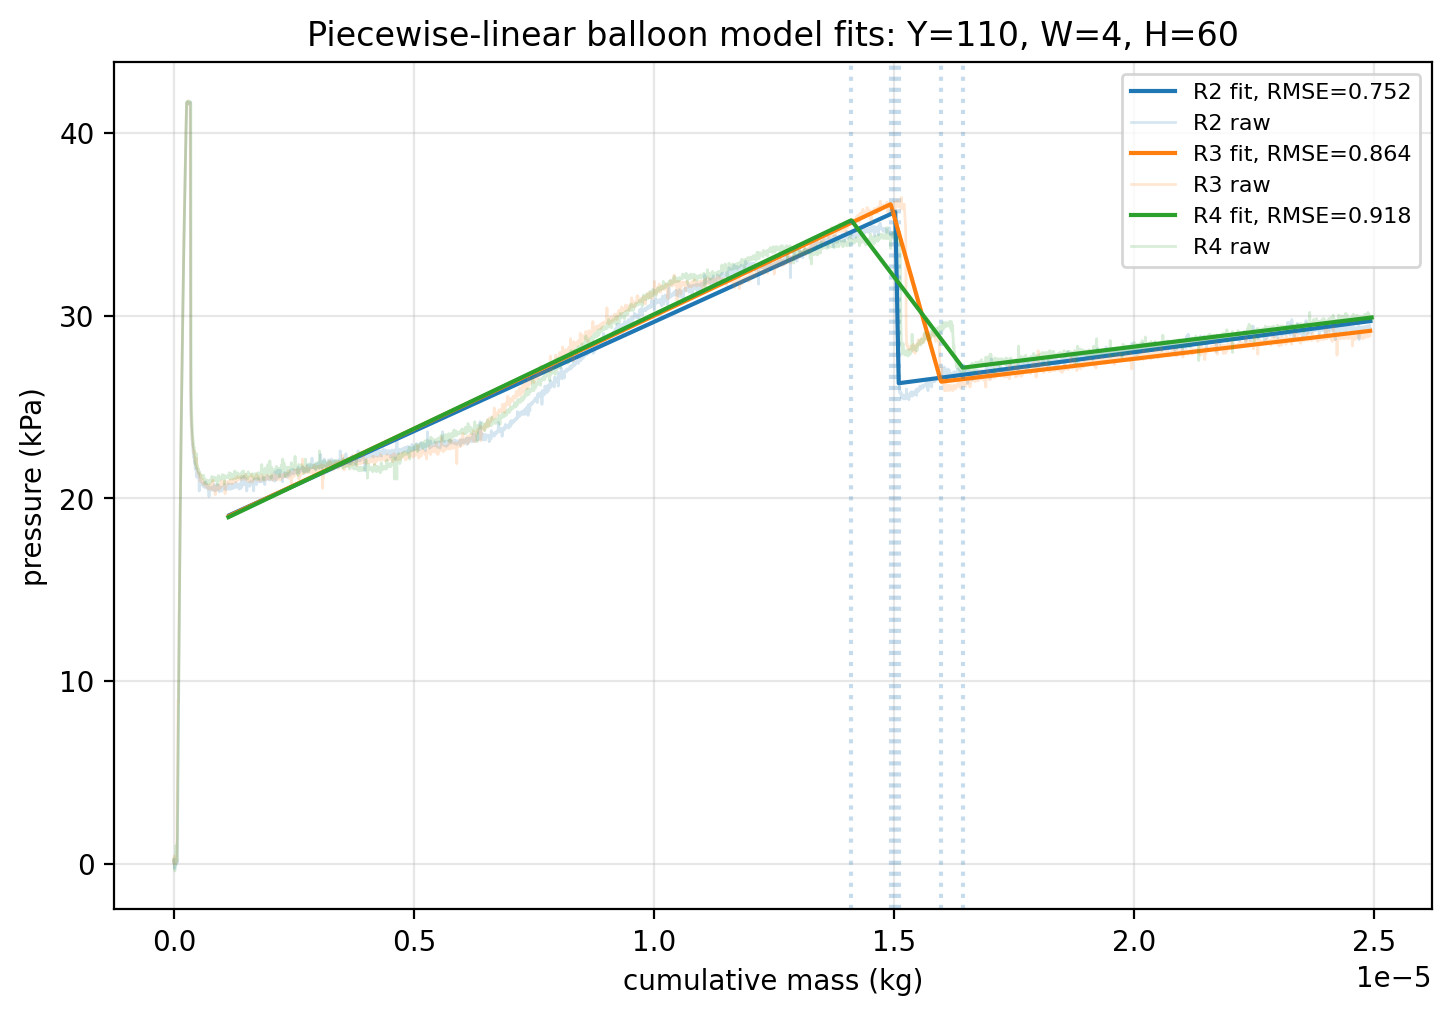

In [38]:
runs_by_WH = {
    (2, 40): [1, 2, 3],
    (4, 40): [1, 2, 3],
    (2, 60): [1, 2, 3],
    (4, 60): [2, 3, 4],
}

ax, results, dfs_loaded = plot_all_runs_fitted_model_curves_from_loader_mass(
    folder=FOLDER,
    Y=110,
    W=4,
    H=60,
    runs_by_WH=runs_by_WH,
    model_t_min=6.0,
    show_legend=True,
    fit_kwargs={
        "use_offset": True,
    },
)

plt.show()